In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/robustness/mouse_brain" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [2]:
seed_list = [20260223, 20260224, 20260225, 20260226, 20260227]
adata_list = []
for seed in seed_list:
    adata_result = ad.read_h5ad(os.path.join(SAVE_PATH, f"adata_result_sampled_0.9_{seed}.h5ad"))
    adata_list.append(adata_result)

In [21]:
ct_plot = ['Ext_Hpc_CA1', 'Ext_Hpc_DG1', 'Ext_L5_2', 'Ext_Amy_2', 'Ext_Thal_1', 'Ext_Thal_2', 'Ext_Med']

In [3]:
ct_plot= [#'Astro_HPC',
 #'Astro_HYPO',
 'Ext_Amy_2',
 'Ext_Hpc_CA1',
 'Ext_Hpc_CA3',
 'Ext_Hpc_DG1',
 'Ext_L23',
 'Ext_L5_1',
 'Ext_L5_2',
 #'Ext_L6',
 'Ext_Med',
 'Ext_Pir',
 'Ext_Thal_1',
 'Ext_Thal_2',
 'Inh_1',
 #'Inh_3'333,
 'Inh_4',
 #'Inh_Meis2_3',
 #'Oligo_1',
 #'Oligo_2']
 ]

In [4]:
factors_list = [adata.obsm['factor'] for adata in adata_list]
loadings_list = [adata.varm['loading'] for adata in adata_list]

In [5]:
n_runs = 5
# cell_types = factors_list[0].columns.tolist()
# proportions = adata_list[0].obsm['proportion'][cell_types].mean().sort_values(ascending=False)
# cell_types = proportions.index.tolist()
n_ct = len(ct_plot)

loading_records = []
factor_records = []

for ct in ct_plot:
    filtered_spot = adata_list[0].obsm['proportion'][ct] > 0.0
    coords = adata_list[0].obsm['spatial'][filtered_spot]
    for i, j in combinations(range(n_runs), 2):
        # Gene loading: |Pearson r|
        v1 = loadings_list[i][ct].values.astype(float)
        v2 = loadings_list[j][ct].values.astype(float)
        r, _ = pearsonr(v1, v2)
        loading_records.append({
            'Cell Type': ct, 'Coherence': abs(r),
            'Pair': f'Run {i+1} vs {j+1}'
        })

        # Factor score: |Pearson r|
        common_idx = factors_list[i].index.intersection(factors_list[j].index)
        f1 = factors_list[i].loc[common_idx, ct].values.astype(float)
        f2 = factors_list[j].loc[common_idx, ct].values.astype(float)
        r, _ = pearsonr(f1, f2)
        factor_records.append({
            'Cell Type': ct, 'Coherence': abs(r),
            'Pair': f'Run {i+1} vs {j+1}'
        })

loading_df = pd.DataFrame(loading_records)
factor_df = pd.DataFrame(factor_records)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

# ============================================================
# 全局绘图风格设置 (Nature Communications 标准)
# ============================================================
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

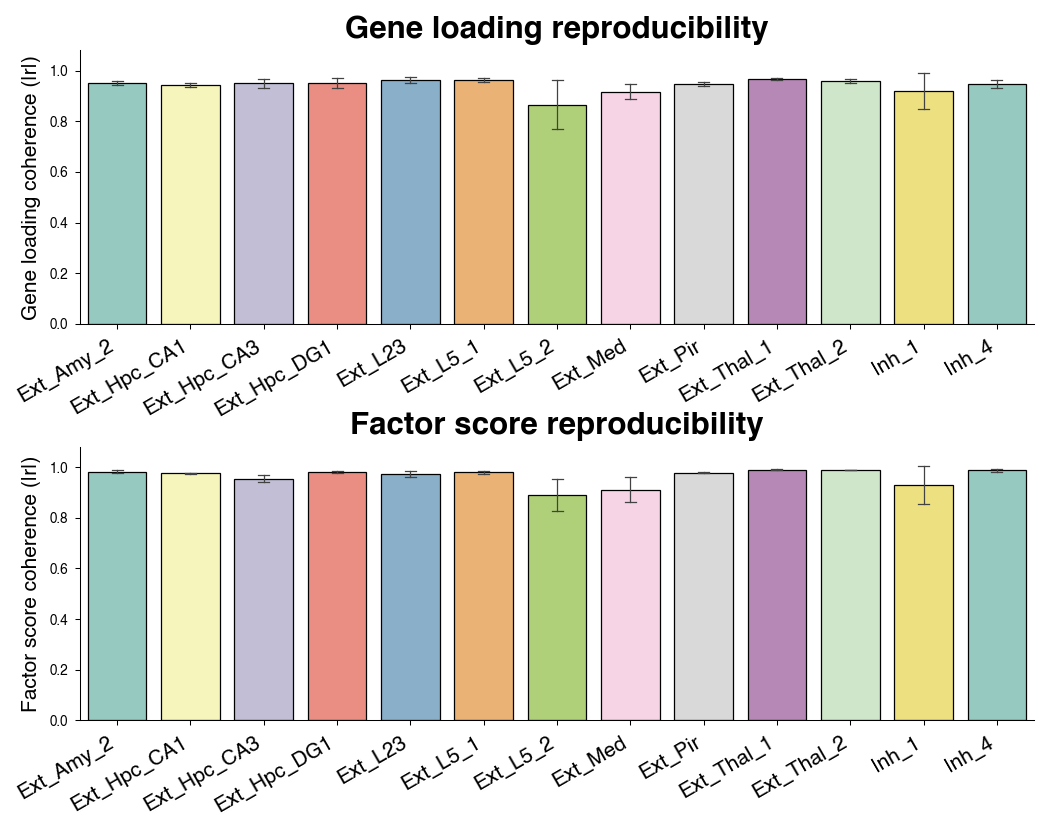

In [9]:
# ============================================================
# 绘图
# ============================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(8.2, 5.8),
    gridspec_kw={'hspace': 0.45}
)

panel_labels = ['a', 'b']
titles = ['Gene loading reproducibility', 'Factor score reproducibility']
ylabels = ['Gene loading coherence (|r|)', 'Factor score coherence (|r|)']
dfs = [loading_df, factor_df]

palette = sns.color_palette('Set3', n_colors=n_ct)

for ax, df, title, ylabel, label in zip(axes, dfs, titles, ylabels, panel_labels):

    # --- Barplot (均值 + 95% CI) ---
    sns.barplot(
        data=df, x='Cell Type', y='Coherence',
        order=ct_plot, ax=ax,
        palette=palette,
        edgecolor='black', linewidth=0.6,
        errorbar='sd', capsize=0.15,
        err_kws={'linewidth': 0.6},
    )

    ax.set_title(title, fontsize=15, fontweight='bold', pad=6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.08)
    ax.set_yticks(np.arange(0, 1.2, 0.2))

    ax.set_xticklabels(ct_plot, rotation=30, ha='right', fontsize=10)

    # ax.text(
    #     -0.06, 1.12, label,
    #     transform=ax.transAxes,
    #     fontsize=10, fontweight='bold',
    #     va='top', ha='left'
    # )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#axes[1].set_xlabel('Cell type', fontsize=7)

plt.savefig('reproducibility_resampling.pdf',
            bbox_inches='tight', pad_inches=0.05)
plt.savefig('reproducibility_resampling.png',
            bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

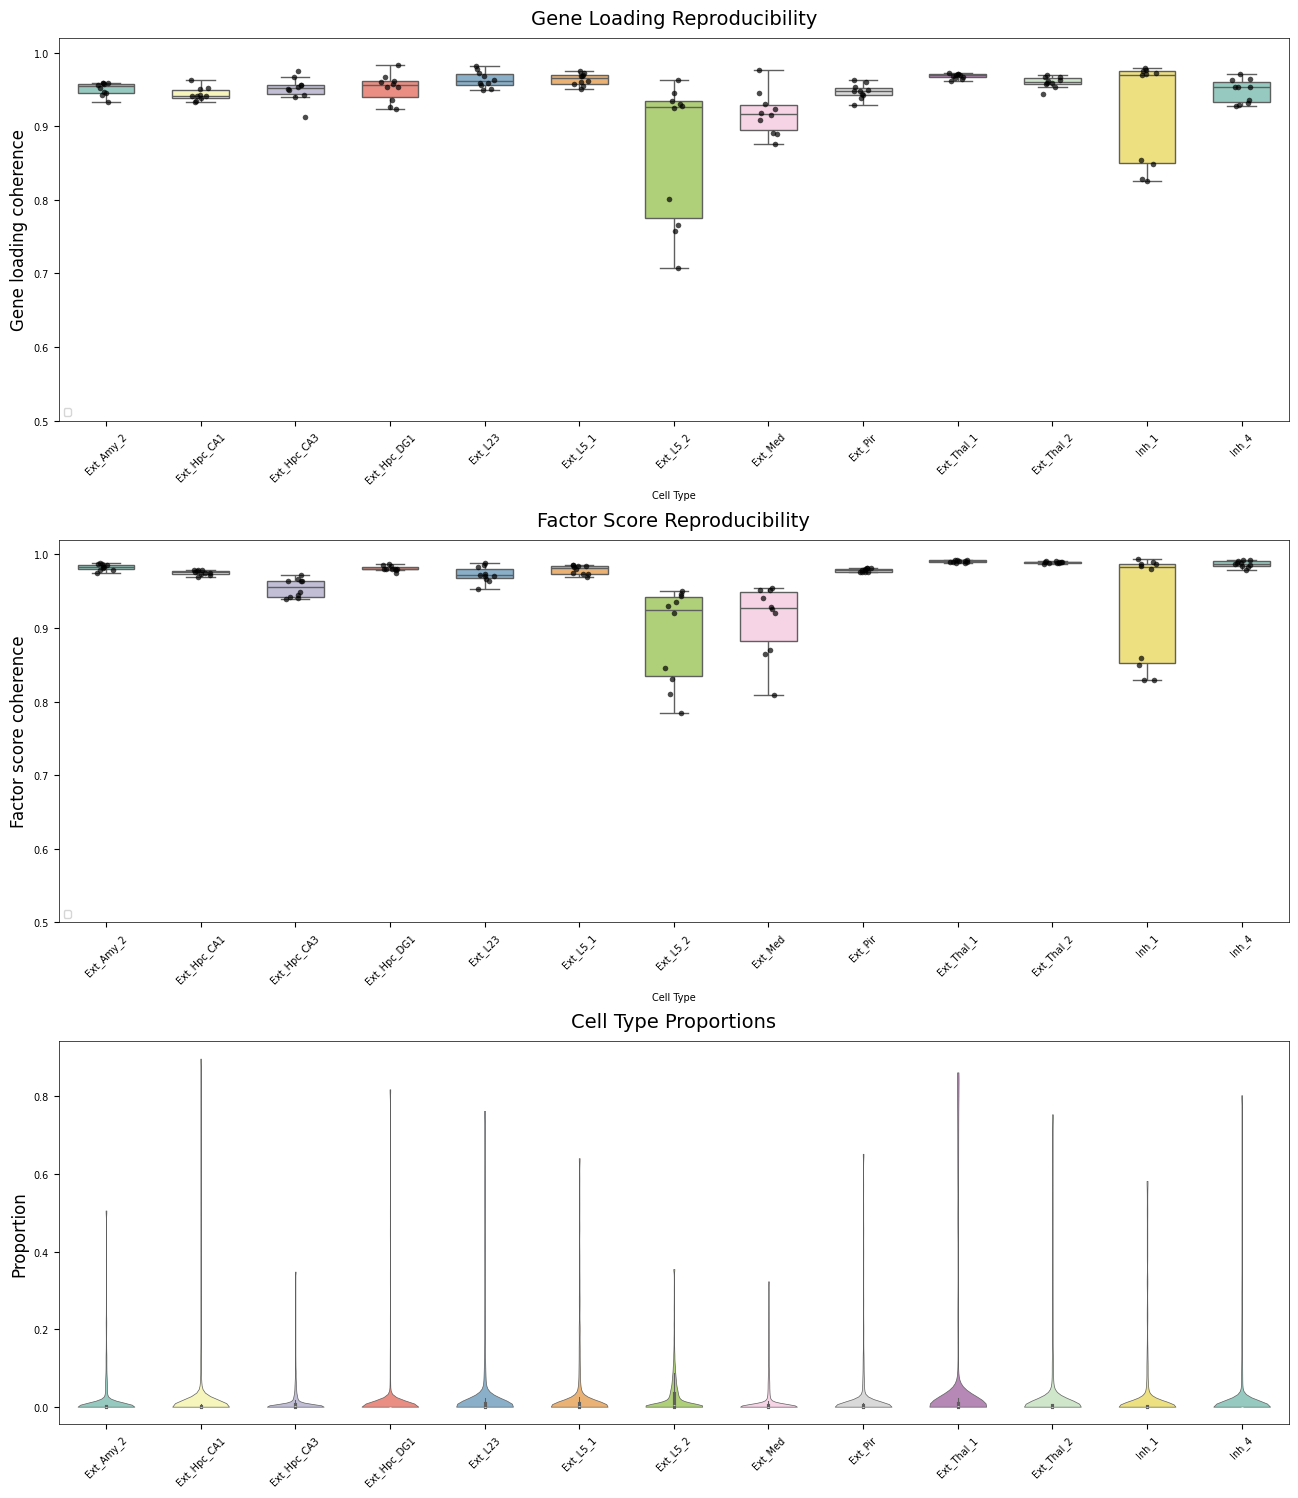

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr

n_runs = len(factors_list)
cell_types = ct_plot
n_ct = len(cell_types)

# ============================================================
# 逐 cell type、逐 pair 计算指标（取绝对值应对符号翻转）
# ============================================================
loading_records = []
factor_records = []

for ct in cell_types:
    for i, j in combinations(range(n_runs), 2):
        # --- Gene loading: |Pearson r| ---
        v1 = loadings_list[i][ct].values.astype(float)
        v2 = loadings_list[j][ct].values.astype(float)
        r, _ = pearsonr(v1, v2)
        loading_records.append({
            'Cell Type': ct, '|Pearson r|': abs(r),
            'Pair': f'Run {i+1} vs {j+1}'
        })

        # --- Factor score: |Pearson r| (共有 spots) ---
        common_idx = factors_list[i].index.intersection(factors_list[j].index)
        f1 = factors_list[i].loc[common_idx, ct].values.astype(float)
        f2 = factors_list[j].loc[common_idx, ct].values.astype(float)
        r_f, _ = pearsonr(f1, f2)
        factor_records.append({
            'Cell Type': ct, '|Pearson r|': abs(r_f),
            'Pair': f'Run {i+1} vs {j+1}'
        })

loading_df = pd.DataFrame(loading_records)
factor_df = pd.DataFrame(factor_records)

# ============================================================
# 画图: 上下两张
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(max(10, n_ct * 1.0), 15))

# ---------- 上: Gene Loading |Pearson r| ----------
sns.boxplot(data=loading_df, x='Cell Type', y='|Pearson r|',
            order=cell_types, ax=axes[0], palette='Set3',
            width=0.6, fliersize=0)
sns.stripplot(data=loading_df, x='Cell Type', y='|Pearson r|',
              order=cell_types, ax=axes[0],
              color='black', size=4, alpha=0.7, jitter=True)
axes[0].set_title('Gene Loading Reproducibility', fontsize=14, pad=10)
axes[0].set_ylabel('Gene loading coherence', fontsize=12)
axes[0].legend(loc='lower left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='center')
#axes[0].set_ylim(max(loading_df['|Pearson r|'].min() - 0.05, 0), 1.02)
axes[0].set_ylim(0.5, 1.02)

# ---------- 下: Factor Score |Pearson r| ----------
sns.boxplot(data=factor_df, x='Cell Type', y='|Pearson r|',
            order=cell_types, ax=axes[1], palette='Set3',
            width=0.6, fliersize=0)
sns.stripplot(data=factor_df, x='Cell Type', y='|Pearson r|',
              order=cell_types, ax=axes[1],
              color='black', size=4, alpha=0.7, jitter=True)
axes[1].set_title('Factor Score Reproducibility', fontsize=14, pad=10)
axes[1].set_ylabel('Factor score coherence', fontsize=12)
axes[1].legend(loc='lower left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='center')
# axes[1].set_ylim(max(factor_df['|Pearson r|'].min() - 0.05, 0), 1.02)
axes[1].set_ylim(0.5, 1.02)

# proportion = adata_list[0].obsm['proportion'][ct_plot]
# # violin plot
# sns.violinplot(data=proportion, palette='Set3', ax=axes[2], width=0.6)
# axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='center')
# axes[2].set_title('Cell Type Proportions', fontsize=14, pad=10)
# axes[2].set_ylabel('Proportion', fontsize=12)

proportion = adata_list[0].obsm['proportion'][ct_plot]

# 按每列99th百分位截断
proportion_clipped = proportion.clip(
    upper=proportion.quantile(0.99), axis=1
)

sns.violinplot(
    data=proportion_clipped,
    palette='Set3',
    ax=axes[2],
    width=0.6,
    cut=0,           # 不让KDE延伸到数据范围外
    bw_adjust=0.6,   # 收紧带宽，violin更贴合
    scale='width',   # 等宽便于比较
    inner='box',
    linewidth=0.5
)

axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='center')
axes[2].set_title('Cell Type Proportions', fontsize=14, pad=10)
axes[2].set_ylabel('Proportion', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import os

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

cell_types = ['B-cell', 'EC', 'Epi_PT', 'Epi_non-PT',
              'Fibro', 'Myeloid', 'RCC', 'T-cell']

# 假设 plot_df 有列: celltype, proportion
clip_upper = plot_df.groupby('celltype')['proportion'].transform(
    lambda x: np.percentile(x, 99)
)
plot_df['proportion_clipped'] = plot_df['proportion'].clip(upper=clip_upper)

fig, ax = plt.subplots(figsize=(7.09, 2.5))

palette = sns.color_palette('Set2', n_colors=len(cell_types))

sns.violinplot(
    data=plot_df,
    x='celltype', y='proportion_clipped',
    order=cell_types,
    palette=palette,
    cut=0,
    bw_adjust=0.6,
    scale='width',
    inner='box',
    linewidth=0.5,
    ax=ax
)

# 内部box样式调细
for l in ax.lines:
    l.set_linewidth(0.4)
for c in ax.collections:
    c.set_edgecolor('black')
    c.set_linewidth(0.3)

ax.set_xlabel('')
ax.set_ylabel('Cell type proportion', fontsize=7)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=6)
sns.despine(ax=ax, trim=True)

# plt.savefig(
#     os.path.join(FIG_PATH, 'celltype_proportion_violin.pdf'),
#     dpi=300, bbox_inches='tight', transparent=True
# )
plt.show()

NameError: name 'plot_df' is not defined

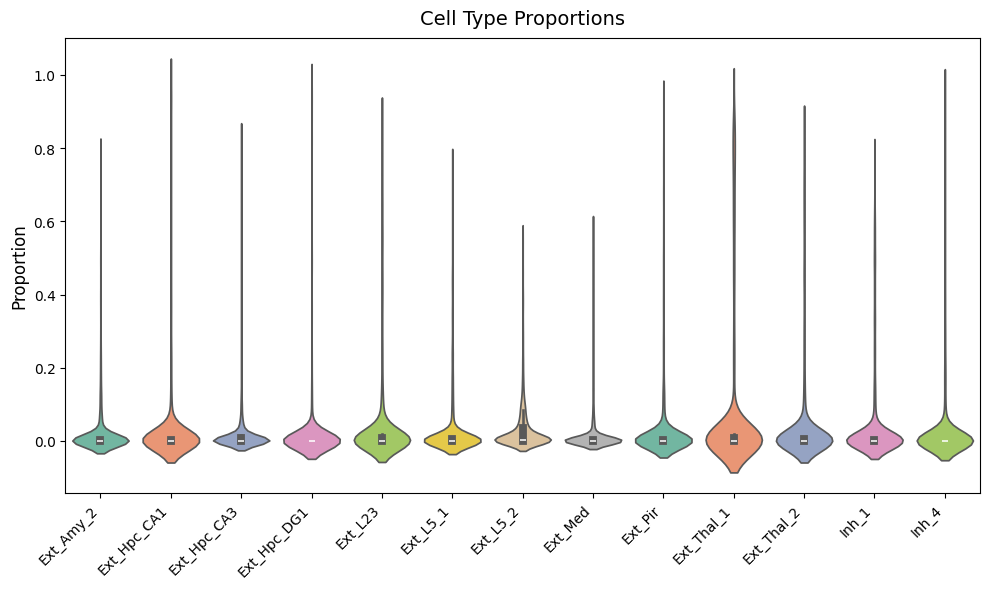

In [14]:
proportion = adata_list[0].obsm['proportion'][ct_plot]
# violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=proportion, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Cell Type Proportions', fontsize=14, pad=10)
plt.ylabel('Proportion', fontsize=12)
plt.tight_layout()
plt.show()

Dropping cell types: ['Ext_Med']


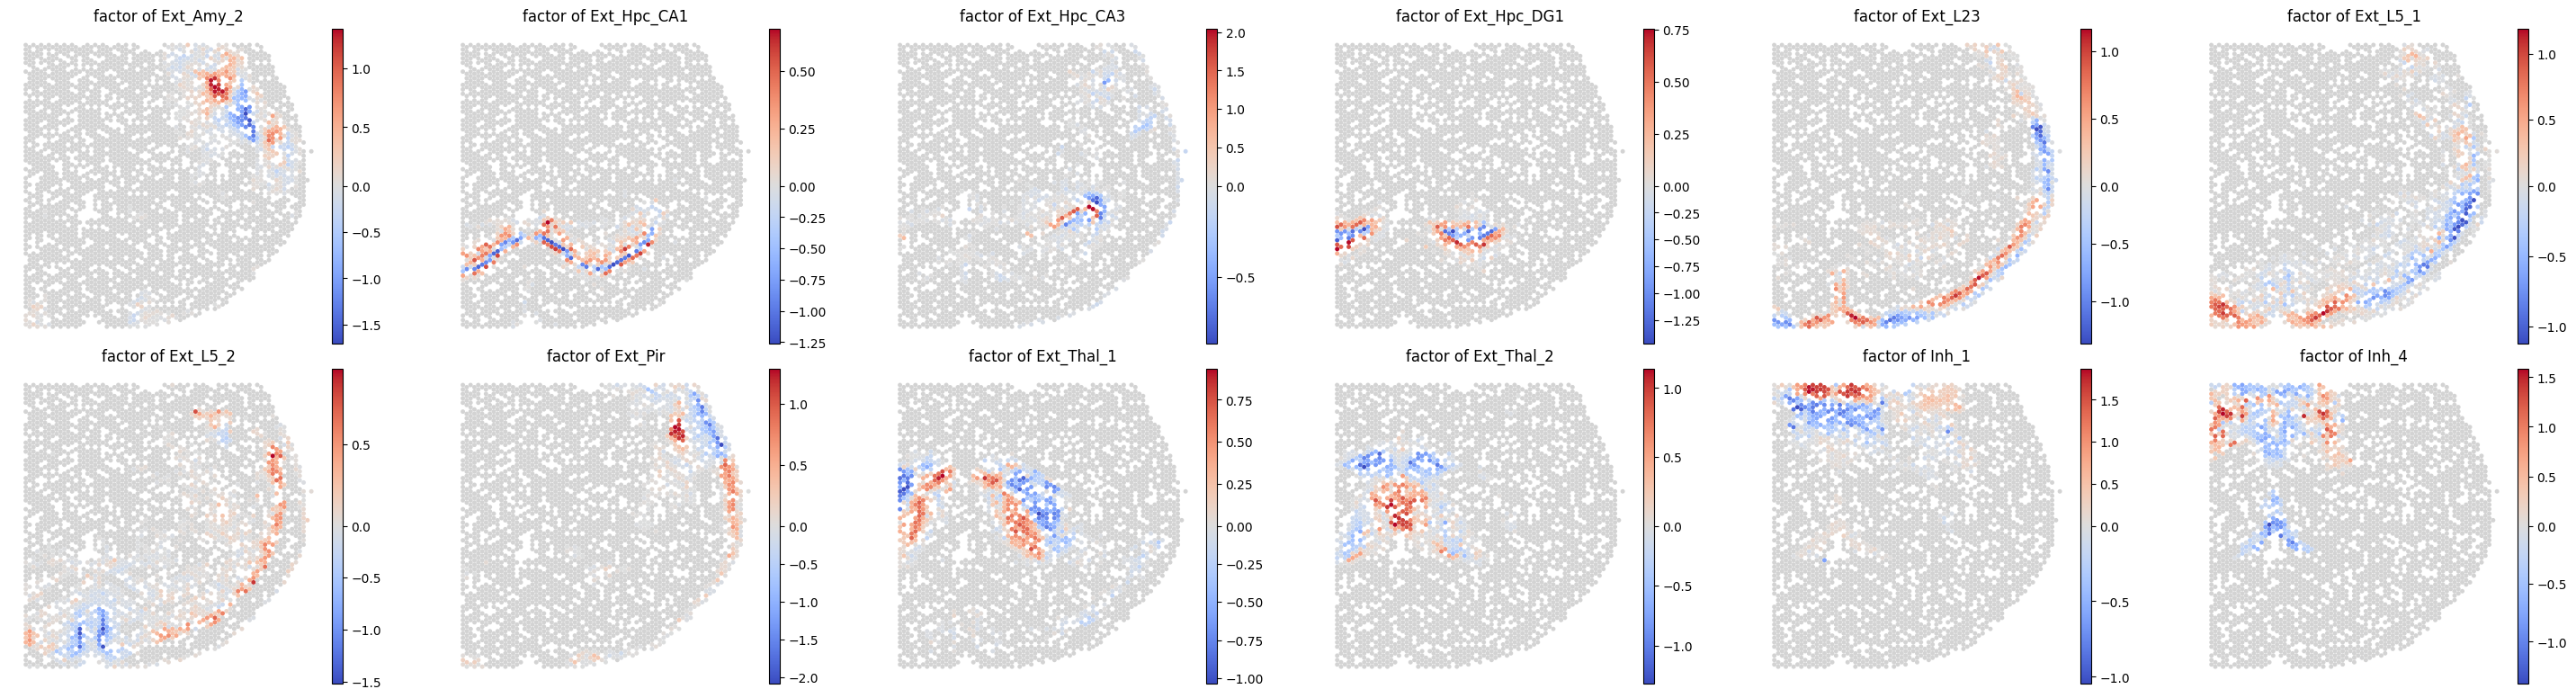

In [17]:
from MacSGP.vis import plot_spatial_ct

plot_spatial_ct(adata_list[4], index='factor', hide_image=True, celltype_plot=ct_plot,
                proportion_threshold=0.01, num_threshold=100, 
                cmap='coolwarm', 
                spot_size=100, 
                ncols=6)

Dropping cell types: []


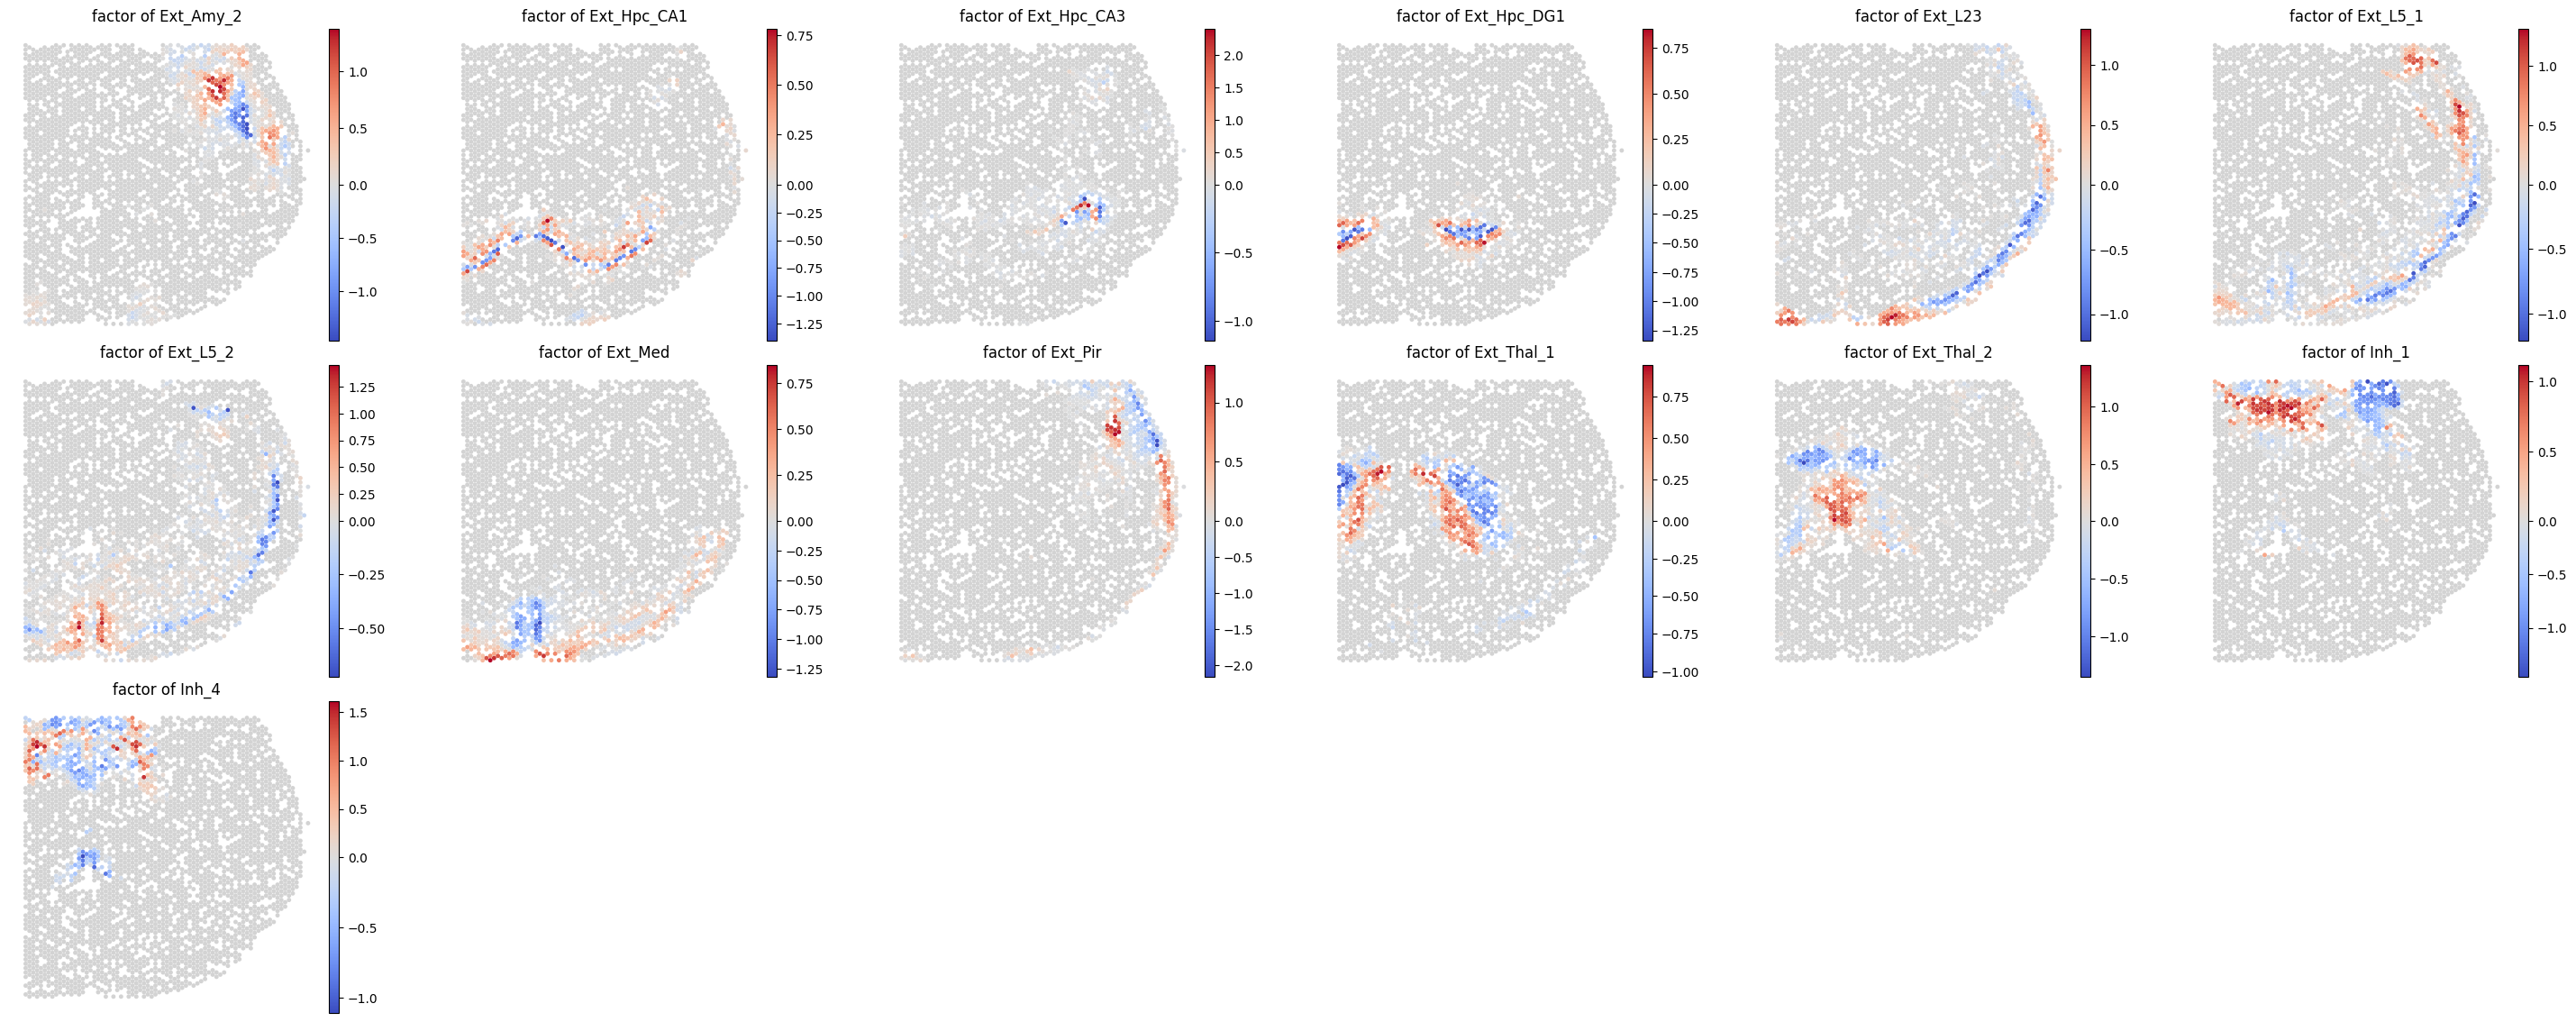

In [19]:
from MacSGP.vis import plot_spatial_ct

plot_spatial_ct(adata_list[1], index='factor', hide_image=True, celltype_plot=ct_plot,
                proportion_threshold=0.01, num_threshold=100, 
                cmap='coolwarm', 
                spot_size=100, 
                ncols=6)